# Clasificación de clientes de una operadora

Integrantes:
- Edison C
- Henry Perz
- Diego Vaca

In [29]:
#pip install streamlit

In [30]:
# Importación de dependencias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib
import streamlit as st


## Selección y exploración del dataset

In [31]:
# Carga de datos
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploración Inicial

In [32]:
# Verificación de tipo de variables y nulos
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Limpieza y Preprocesamiento

In [33]:
# Convertir la columna 'TotalCharges' a tipo numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Manejar los valores nulos en 'TotalCharges' reemplazándolos con la mediana
mediana_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_total_charges)

# Convertir la variable objetivo 'Churn' a valores binarios
df['Churn'] = df['Churn'].map({'No':0,'Yes':1}).astype(int)

## Visualización

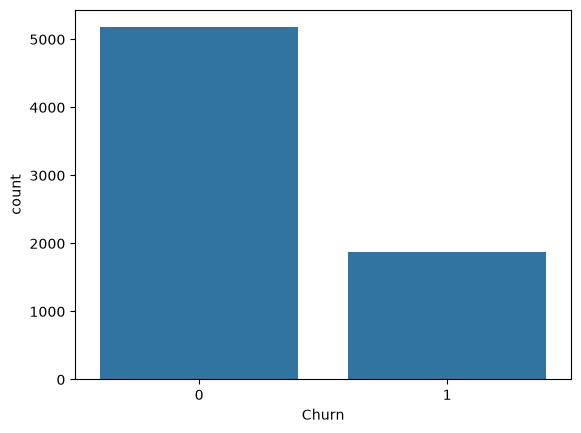

In [34]:
# Visualización de la variable 'Churn'
sns.countplot(x='Churn', data=df)
plt.show()

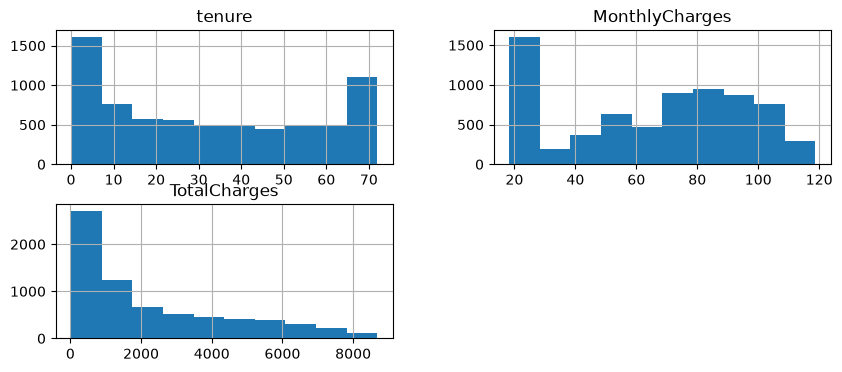

In [35]:
# Selección de variables numéricas
numericas=['tenure','MonthlyCharges','TotalCharges']
df[numericas].hist(figsize=(10,4))
plt.show()

C:\Users\DRVACAE\AppData\Local\Temp\ipykernel_18168\3689614641.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(df.select_dtypes(include=['object']).columns)


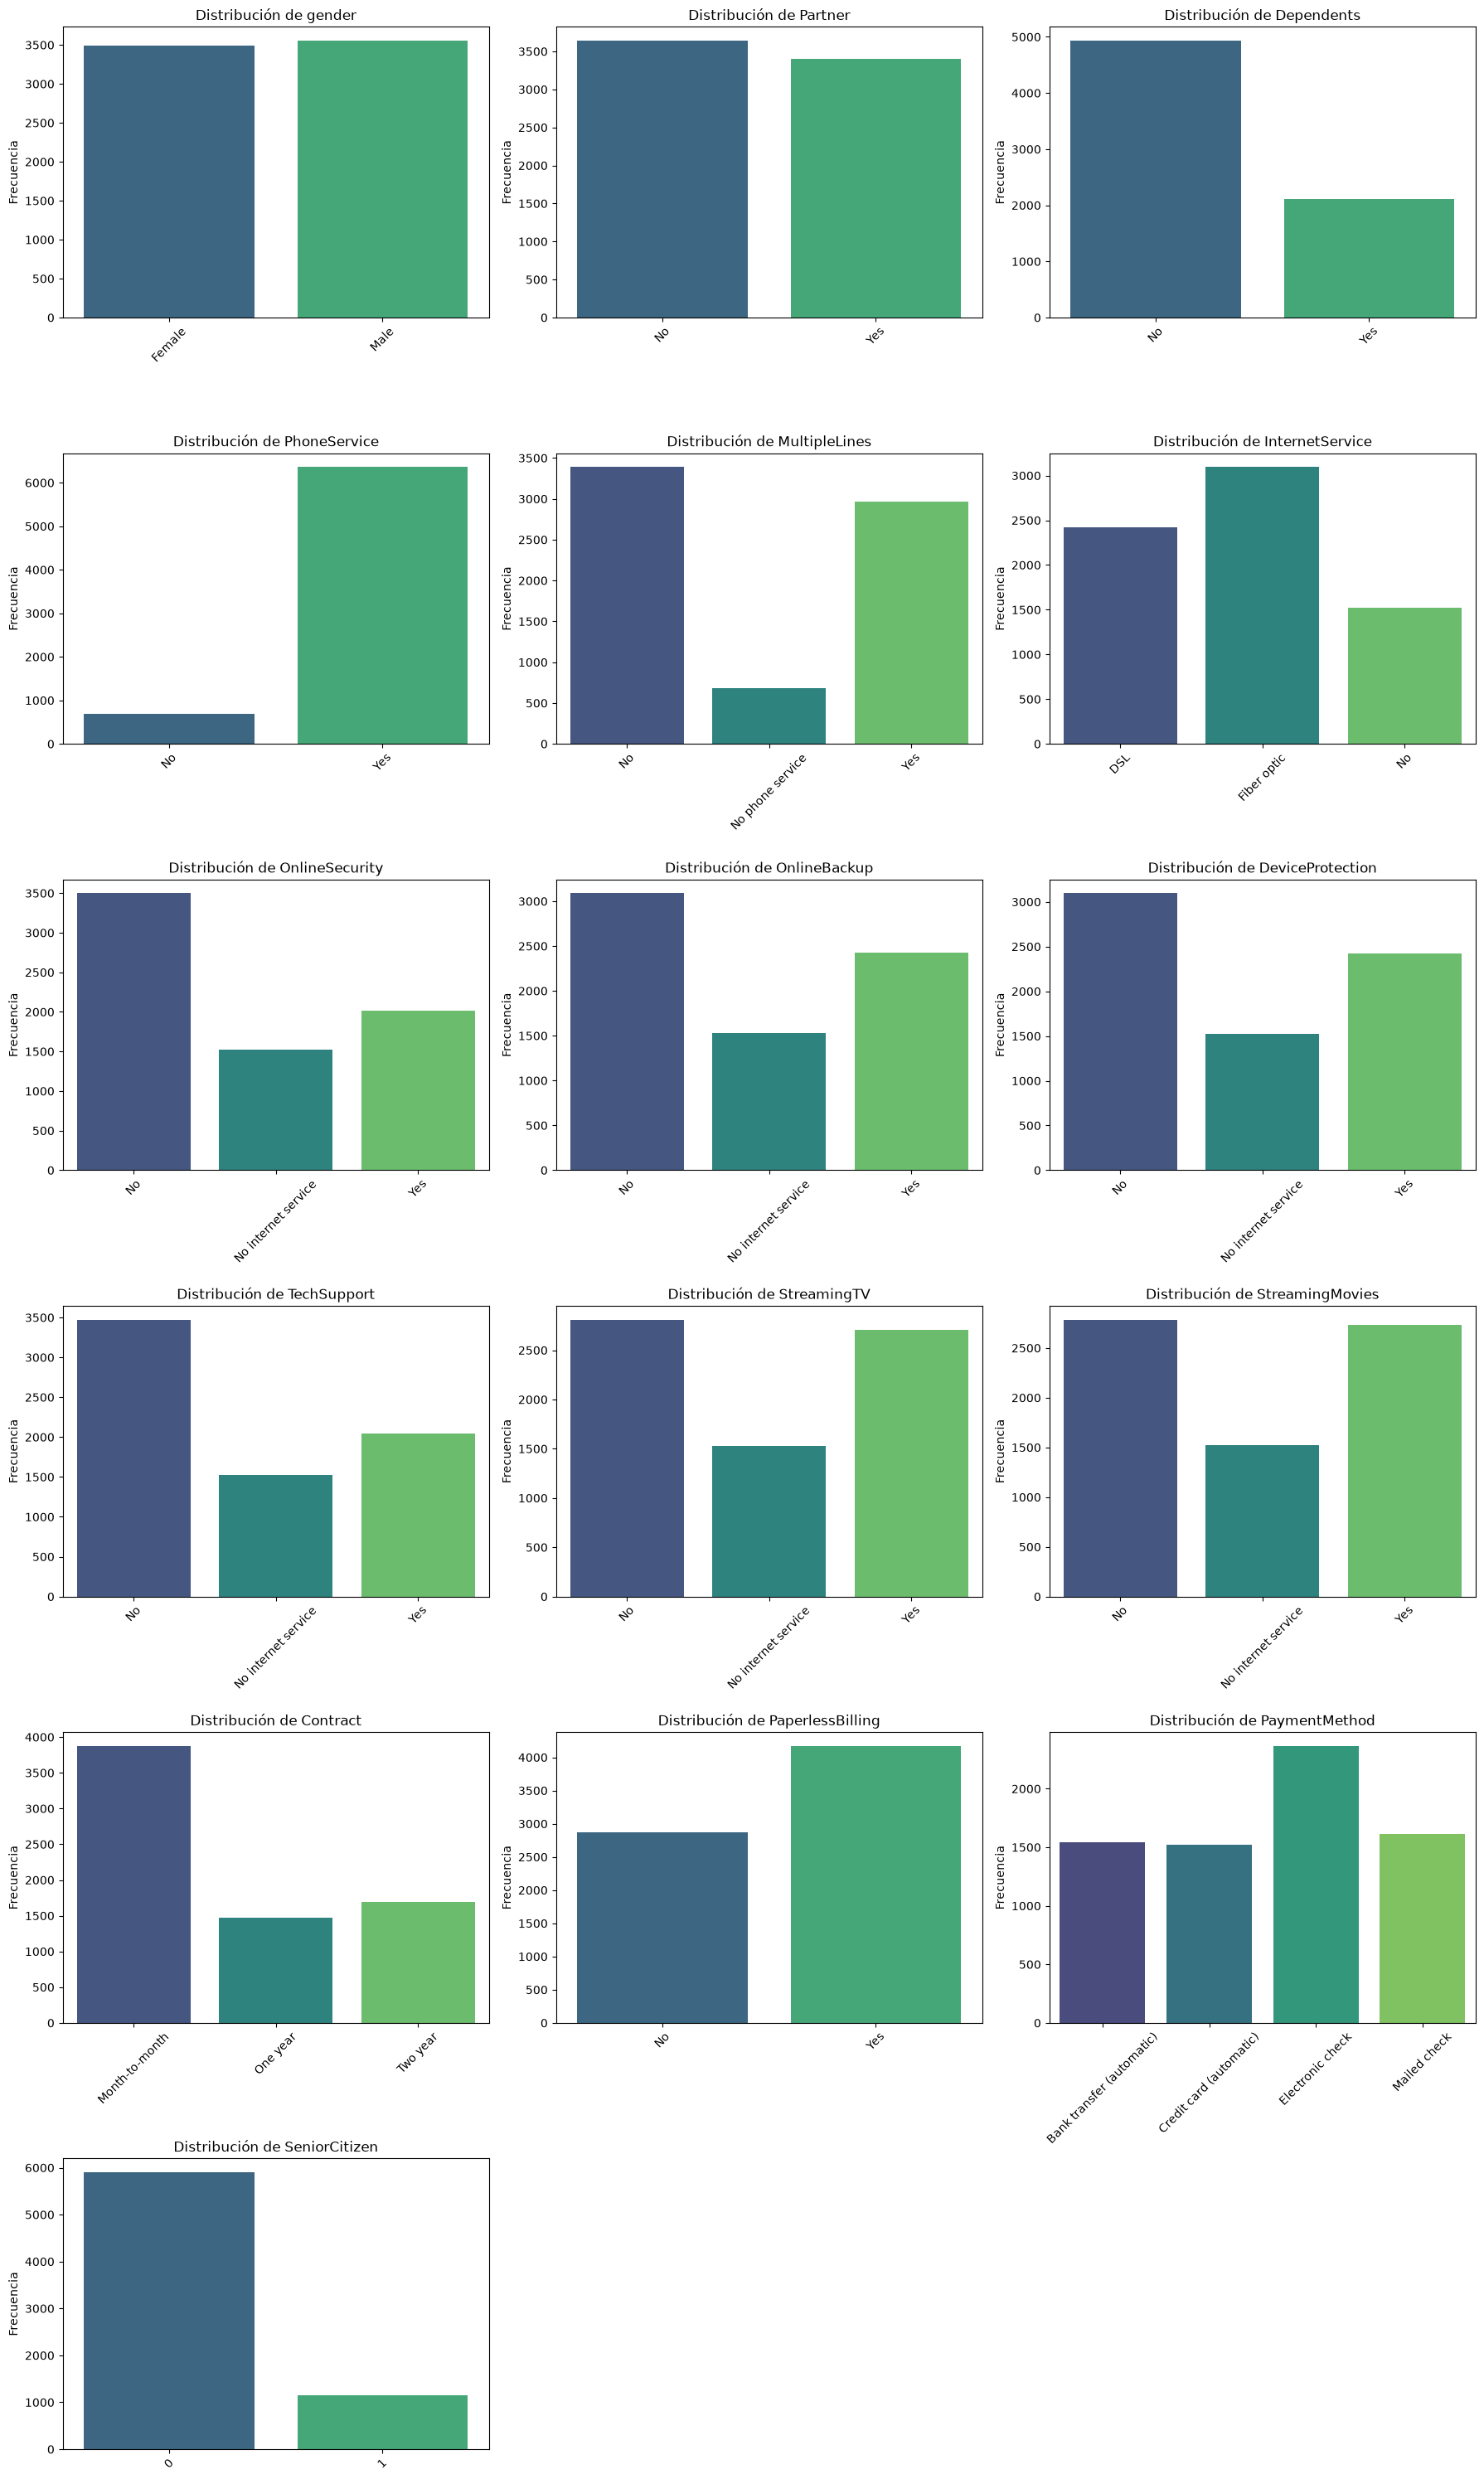

In [36]:
# Variables categóricas tipo object
cat_cols = list(df.select_dtypes(include=['object']).columns)

# Eliminar customerID
cat_cols.remove("customerID")

# Incorporar SeniorCitizen manualmente
cat_cols.append("SeniorCitizen")

# Número de gráficos
n = len(cat_cols)

n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# Graficar distribuciones
for i, col in enumerate(cat_cols):

    frecuencias = df[col].value_counts().sort_index()

    sns.barplot(
        x=frecuencias.index.astype(str),
        y=frecuencias.values,
        ax=axes[i],
        hue=frecuencias.index.astype(str),
        legend=False,
        palette="viridis"
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [37]:
# Convertir variables categóricas a variables dummy
df = pd.get_dummies(df, drop_first=True)

## División de Datos

In [38]:
#Selección de la variable objetivo
X = df.drop('Churn',axis=1)

#Selección de las variables predictoras
y = df['Churn']

# Definición de datos de entrenamiento y prueba
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Escalamiento de variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modelo kNN

In [39]:
# Se enterena el modelo KNN con k=9
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)

# Valores predecidos
y_pred = knn.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [40]:
# Cálculo del accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Exactitud del modelo: {acc:.4f}')

Exactitud del modelo: 0.7637


In [41]:
# Imprimir reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85      1035
           1       0.57      0.44      0.49       374

    accuracy                           0.76      1409
   macro avg       0.69      0.66      0.67      1409
weighted avg       0.75      0.76      0.75      1409



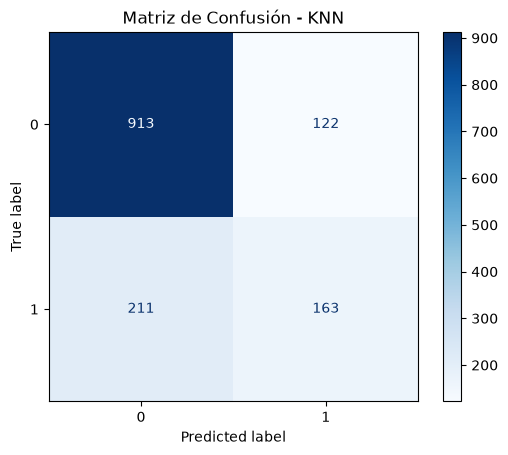

In [42]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Gráfico de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - KNN")
plt.show()

In [43]:
# Entrenar el modelo Random Forest
clf = RandomForestClassifier(n_estimators=10) # n_estimators es el número de árboles en el bosque
clf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [44]:
# Imprimo el reporte de clasificación
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1035
           1       0.58      0.78      0.67       374

    accuracy                           0.79      1409
   macro avg       0.75      0.79      0.76      1409
weighted avg       0.82      0.79      0.80      1409



C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
# Obtener la importancia de las características
importances = clf.feature_importances_
print(importances)

# Imprimir las características
feature_names = X.columns
print(feature_names)

[0.01402448 0.08613634 0.08315076 ... 0.01116093 0.03123626 0.00810218]
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str', length=7072)


In [46]:
# Crear un DataFrame de las características y su importancia
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print(feature_importances)

                             feature  importance
3                       TotalCharges    0.099652
1                             tenure    0.086136
2                     MonthlyCharges    0.083151
7052     InternetService_Fiber optic    0.036886
7070  PaymentMethod_Electronic check    0.031236
...                              ...         ...
5755           customerID_8092-NLTGF    0.000000
222            customerID_0336-KXKFK    0.000000
223            customerID_0336-PIKEI    0.000000
5737           customerID_8069-RHUXK    0.000000
995            customerID_1442-BQPVU    0.000000

[7072 rows x 2 columns]


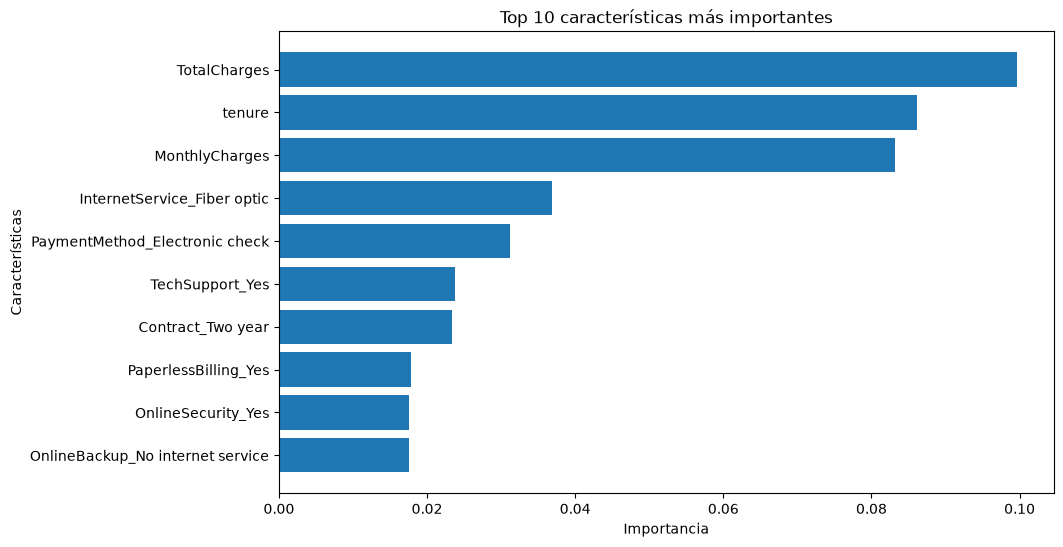

In [47]:
# Visualizar la importancia de las características
# Tomar solo las 10 características más importantes
top10 = feature_importances.head(10)

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()  # Para que la más importante aparezca arriba
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Top 10 características más importantes")
plt.show()

In [48]:
# Mostrar las dos (2) características más importantes
print("Las dos características más importantes son:")
print(feature_importances.head(3))

Las dos características más importantes son:
          feature  importance
3    TotalCharges    0.099652
1          tenure    0.086136
2  MonthlyCharges    0.083151


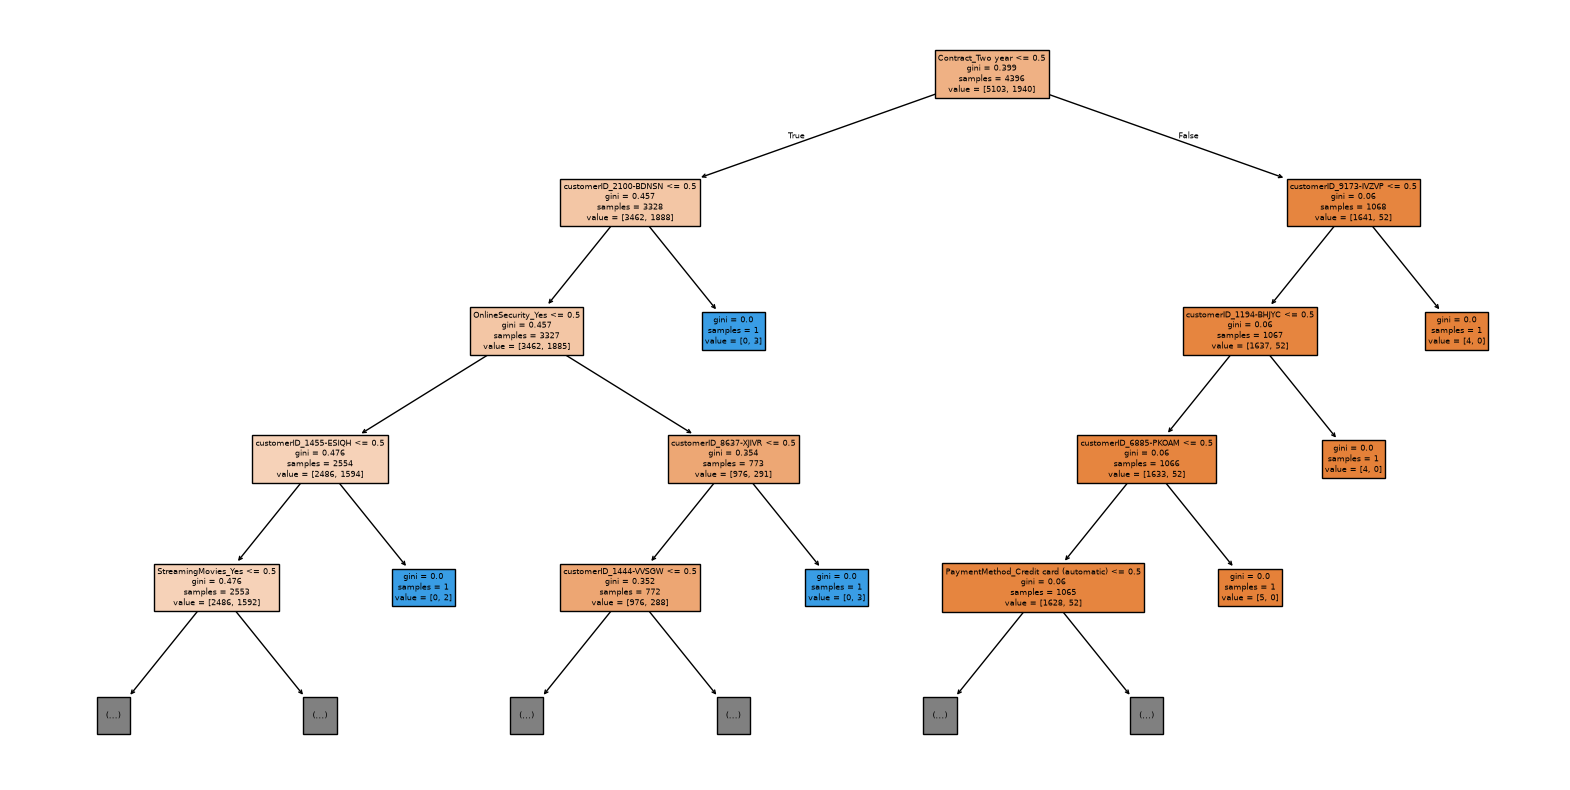

In [49]:
# Ploteamos un árbol de decisión
plt.figure(figsize=(20, 10))
plot_tree(
    clf.estimators_[3],
    feature_names=feature_names,
    filled=True,
    max_depth=4   # Muestra solo los primeros niveles
)
plt.show()


## Modelo MLP

In [50]:
# Entrenamiento del modelo MLP
mlp=MLPClassifier(hidden_layer_sizes=(64,32),activation='relu',solver='adam',max_iter=300,random_state=42)
mlp.fit(X_train,y_train)
y_pred_mlp=mlp.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

Accuracy: 0.7345635202271115
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

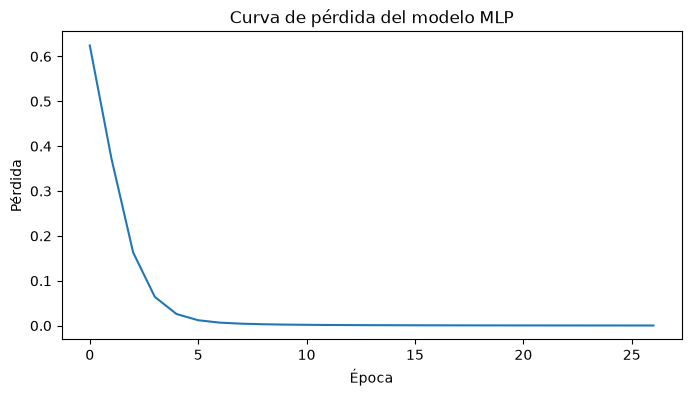

In [51]:
# Curva de pérdida del modelo MLP
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida del modelo MLP")
plt.show()

In [52]:
# Comparación entre valores reales y predichos
comparacion = pd.DataFrame({
    "Valor Real": y_test,
    "Predicción": y_pred_mlp
})

comparacion.head()

,Valor Real,Predicción
437,0,0
2280,0,0
2235,0,0
4460,0,0
3761,0,0


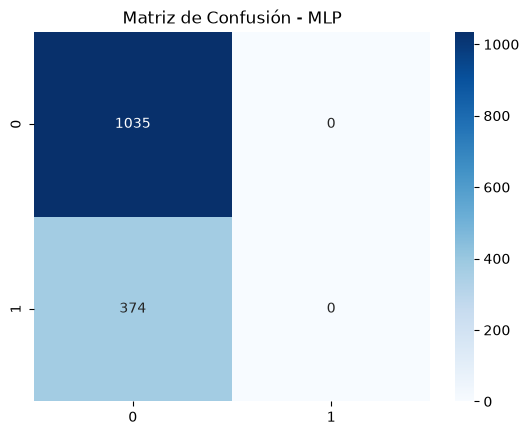

In [53]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - MLP")
plt.show()

## Comparación y Exportación

In [54]:
# Comparación de modelo knn y MLP
acc_knn=accuracy_score(y_test,y_pred)
acc_mlp=accuracy_score(y_test,y_pred_mlp)
print({'kNN':acc_knn,'MLP':acc_mlp})


{'kNN': 0.7927608232789212, 'MLP': 0.7345635202271115}


## Preparación de la aplicación para despliegue

In [55]:
# Reentrenamiento del modelo MPL con las caracteristicas mas importantes
# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation="relu",
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
print('Accuracy:',accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

joblib.dump(mlp,'modelo_churn.pkl')
joblib.dump(scaler,'scaler.pkl')

Accuracy: 0.7345635202271115
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DRVACAE\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

['scaler.pkl']